### 05. Cross-matching the Duque et al. catalogue with eRASS:1


**Author**: Soumya Shreeram <br/>
**Date created**: 28th April 2022 <br/>
**Last edited**: tbu <br/>

In [1]:
# astropy modules
import astropy.units as u
import astropy.io.fits as fits

from astropy.table import Table, Column, join
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM, z_at_value

import numpy as np

# system imports
import os
import sys
import importlib as ib
import glob
import gzip
import copy

# plotting imports
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

import seaborn as sns
import pandas as pd

import healpy as hp
from healpy.newvisufunc import projview, newprojplot
from skimage.morphology import skeletonize
from skimage import data
from skimage.util import invert

In [2]:
mpl.rcParams['agg.path.chunksize'] = 100000
%matplotlib inline
font = {'family' : 'serif',
        'weight' : 'medium',
        'size'   : 16}
mpl.rc('font', **font)

bright_colors = sns.color_palette("bright")

In [3]:
import filaments as fo

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
base_dir = "/data53s/shreeram/Filament_stacking"
code_dir = f"{base_dir}/code"
image_dir = f"{base_dir}/images"
data_dir = f"{base_dir}/data/Cluster_catalogs"

In [6]:
z_low, z_high = 0.31, 0.32
z_range = (z_low, z_high)

NSIDE = 256

val_erass1 = 1
val_act = val_erass1+1
val_psz = val_act+1
val_combined = val_psz+1
val_filament=val_combined+16

reso = hp.pixelfunc.nside2resol(NSIDE, arcmin=True)

#### Load the cluster catalog

In [7]:
cluster_cat_eRASS1 = fo.ClusterCatalogs(redshift_range=z_range)

# produce the healpy maps with discs around the clusters
eRASS1 = cluster_cat_eRASS1.get_healpy_clusters_map(fil_pixel_cluster_disc=val_erass1)
cluster_map, clu_map_with_discs, clu_pix_idx = eRASS1

INFO:ClusterCatalogs:Default cluster catalog set to `eRASS1`
INFO:ClusterCatalogs:Other options include: PSZ, ACT
INFO:ClusterCatalogs:Selecting in the redshift bin 0.31<z<0.32


#### Load the filament catalogue

In [8]:
this_fil_duque21 = fo.Filaments(filament_catalogue_name='Duque_2021_SDSS')
plot_obj_duque21 = fo.DoPlotFilaments(this_fil_duque21)

# open the filament catalogue
fil_table, ra_og, dec_og = this_fil_duque21.open_fil_cat()
ra_fil, dec_fil = this_fil_duque21.choose_z_unc(fil_table=fil_table, ra_og=ra_og, dec_og=dec_og)

INFO:Filaments:Default param 'which_redshifts=lowz'  
INFO:numexpr.utils:Note: detected 160 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
INFO:numexpr.utils:Note: NumExpr detected 160 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.


#### Generate healpy maps for cross-matching the nodes with the filament catalog


In [9]:
filament_map, fil_pix_idx = fo.produce_healpy_map(NSIDE, ra_fil, dec_fil, return_pixel_idx=True,
                                                 fil_val=val_filament)

In [10]:
# get the ra and dec for the pixels in radians (lonlat=False)
theta_fil, phi_fil = hp.pixelfunc.pix2ang(nside=NSIDE, ipix=fil_pix_idx, nest=True)
theta_clu, phi_clu  = hp.pixelfunc.pix2ang(nside=NSIDE, ipix=clu_pix_idx, nest=True)

ra_fil, dec_fil = hp.pixelfunc.pix2ang(nside=NSIDE, ipix=fil_pix_idx, nest=True, lonlat=True)
ra_clu, dec_clu  = hp.pixelfunc.pix2ang(nside=NSIDE, ipix=clu_pix_idx, nest=True, lonlat=True)

/home/shreeram/miniconda3/envs/eroconda/lib/python3.7/site-packages/healpy/projaxes.py:211: MatplotlibDeprecationWarning: Passing parameters norm and vmin/vmax simultaneously is deprecated since 3.3 and will become an error two minor releases later. Please pass vmin/vmax directly to the norm when creating it.
  **kwds
/home/shreeram/miniconda3/envs/eroconda/lib/python3.7/site-packages/healpy/projaxes.py:543: UserWarning: 0.0 180.0 -180.0 180.0
  pmin / dtor, pmax / dtor, mmin / dtor, mmax / dtor
/home/shreeram/miniconda3/envs/eroconda/lib/python3.7/site-packages/healpy/projaxes.py:658: UserWarning: The interval between parallels is 30 deg -0.00'.
  vdeg, varcmin
/home/shreeram/miniconda3/envs/eroconda/lib/python3.7/site-packages/healpy/projaxes.py:666: UserWarning: The interval between meridians is 30 deg -0.00'.
  vdeg, varcmin


<MollweideAxesSubplot:>

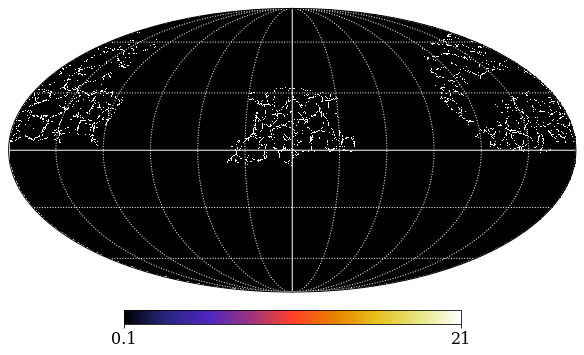

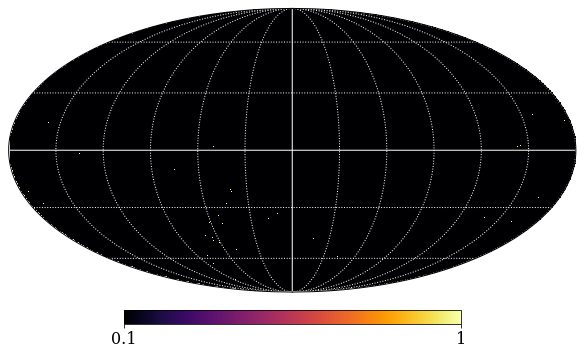

In [11]:
CMRmap = copy.copy(mpl.cm.get_cmap("CMRmap"))
inferno = copy.copy(mpl.cm.get_cmap("inferno"))

norm=mpl.colors.LogNorm(vmin=1e-2, vmax=6)
    
fo.healpy_mollview(filament_map+cluster_map, cmap='CMRmap', norm='hist')
fo.healpy_mollview(cluster_map, cmap=inferno, norm='hist')
#fo.healpy_mollview(cluster_map_masked.filled(), cmap=inferno, vmin=1e-3)

In [12]:
def plot_overlap(theta_fil, phi_fil, theta_clu, phi_clu, theta_min=1.6, phi_min=2, phi_max=4,
                theta_max=None, xlabel=None, ylabel=None):
    fig, ax = plt.subplots(1, 1, figsize=(10,10))

    ax.plot(theta_fil, phi_fil, 'k.', ms=0.1, label='Filaments')
    ax.plot(theta_clu, phi_clu, 'r*', ms=5, label='Clusters/groups', alpha=0.5)

    c = '#40E0D0'
    if theta_max is None:
        theta_max = np.min(theta_clu)
    ax.vlines(theta_min, ymin=np.min(phi_fil), ymax=np.max(phi_fil), color=c, ls='-', lw=2)
    ax.vlines(theta_max, ymin=np.min(phi_clu), ymax=np.max(phi_fil), color=c, ls='-', lw=2)
    ax.hlines(phi_min, xmin=np.min(theta_fil), xmax=np.max(theta_fil))
    ax.hlines(phi_max, xmin=np.min(theta_fil), xmax=np.max(theta_fil))

    overlapping_region = ( (theta_fil) < (theta_min)) & \
                         ( (theta_fil) > (np.min(theta_clu))  ) & \
                         (phi_fil > phi_min) & (phi_fil < phi_max)
    ax.plot(theta_fil[overlapping_region], phi_fil[overlapping_region], '.', c=c, ms=0.6, label='Overlapping values')

    if xlabel and ylabel is None:
        fo.set_labels(ax, r'Theta, $\Theta$ [rad]', r'Phi, $\Phi$ [rad]', legend=False)
    else:
        fo.set_labels(ax, xlabel, ylabel, legend=False)
    l = ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05),
              ncol=3, fancybox=True, shadow=True)
    for legend_handle in l.legendHandles:
        legend_handle._legmarker.set_markersize(12)
    fo.set_as_white(ax)
    return overlapping_region

def plot_overlap_dist(theta_fil, phi_fil, overlapping_region, xlabel_0=None, xlabel_1=None):
    """
    Function to plot the overlapping distribution of the theta/dec - phi/ra 
    Parameters
    ----------
    theta_fil: arr, float
        Usually in radians, but can also pass Dec [deg] and change `xlabel_0='Dec [deg]'` accordingly 
    phi_fil: arr, float
        Phi array usually in rad, but can also pass R.A. [deg] and change `xlabel_1= 'R.A. [deg]'`
    overlapping_region: arr, boolean
        Array outputted by Function `plot_overlap()`, gives the 
    """
    fig, ax = plt.subplots(1, 2, figsize=(10,5))
    _ = ax[0].hist(theta_fil[overlapping_region], color='r', histtype='step', lw=4)
    fo.set_as_white(ax[0])
    if xlabel_0 is None:
        fo.set_labels(ax[0], r'Theta, $\Theta$ [rad]', 'Counts', title=r'Overlaping $\Theta$ values', legend=False)
    else:
        fo.set_labels(ax[0], xlabel_0, 'Counts', title=f'Overlaping {xlabel_0} values', legend=False)

    _ = ax[1].hist(phi_fil[overlapping_region], color='k', histtype='step', lw=4)
    fo.set_as_white(ax[1])
    if xlabel_1 is None:
        fo.set_labels(ax[1], r'Phi, $\Phi$ [rad]', 'Counts', title=r'Overlaping $\Phi$ values', legend=False)
    else:
        fo.set_labels(ax[1], xlabel_1, 'Counts', title=f'Overlaping {xlabel_1} values', legend=False)


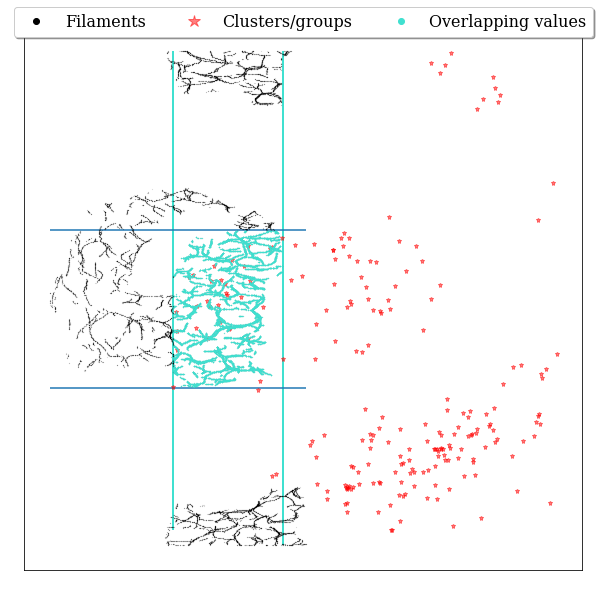

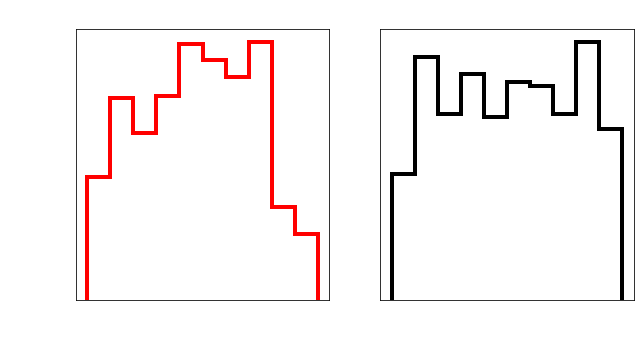

In [13]:
overlap_idx_radians = plot_overlap(theta_fil, phi_fil, theta_clu, phi_clu)
plot_overlap_dist(theta_fil, phi_fil, overlap_idx_radians)

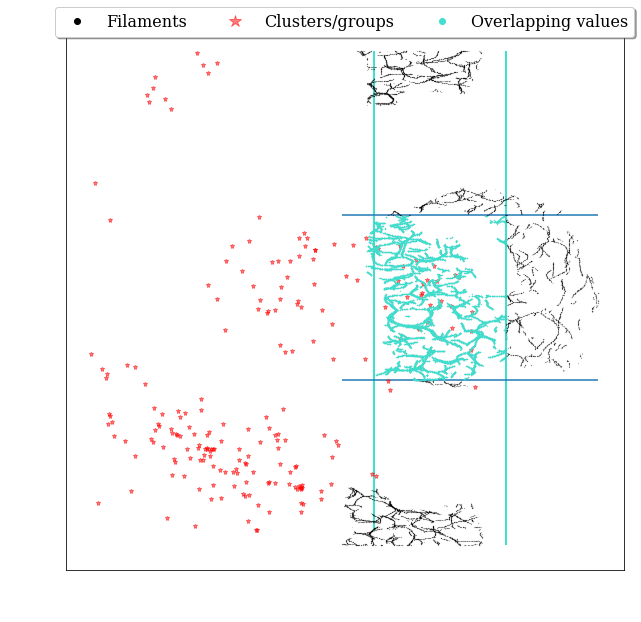

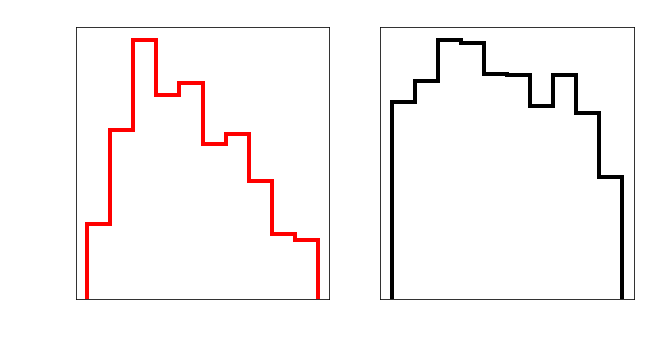

In [14]:
overlap_idx_degs = plot_overlap(dec_fil, ra_fil, dec_clu, ra_clu, 
                                   theta_min = 40, theta_max = 1,
                                   phi_min = 120, phi_max = 240,
                                   xlabel='Dec [deg]', ylabel='R.A [deg]')
plot_overlap_dist(dec_fil, ra_fil, overlap_idx_degs, 
                 xlabel_0 = 'Dec [deg]', xlabel_1 = 'R.A. [deg]')

In [15]:
center_ra, center_dec = 20, 170

/home/shreeram/miniconda3/envs/eroconda/lib/python3.7/site-packages/healpy/projaxes.py:211: MatplotlibDeprecationWarning: Passing parameters norm and vmin/vmax simultaneously is deprecated since 3.3 and will become an error two minor releases later. Please pass vmin/vmax directly to the norm when creating it.
  **kwds


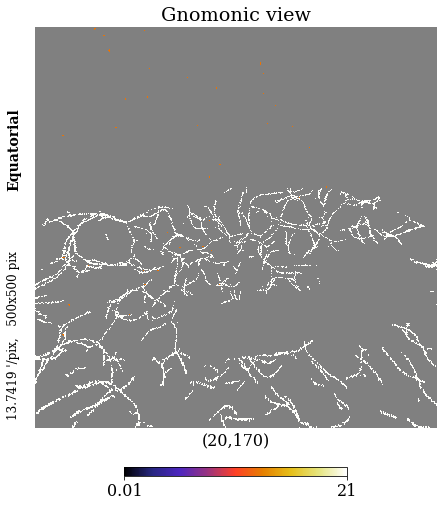

In [16]:
cmap = copy.copy(mpl.cm.get_cmap("CMRmap"))

fig = plt.figure(figsize=(8,9))
ax = plt.subplot(111)

hp.gnomview(filament_map+cluster_map, rot=[center_ra, center_dec, 0 ], coord='C',
           xsize=500, ysize=500, nest=True, hold=True, cmap=cmap, reso=reso, norm='log',
           min=1e-2)

fo.set_labels(ax, "RA", "dec", title="Using gnomview", legend=False)
ax.set_title("Using gnomview", color='w')
fig.patch.set_facecolor('white')

/home/shreeram/miniconda3/envs/eroconda/lib/python3.7/site-packages/healpy/projaxes.py:543: UserWarning: 0.0 180.0 -180.0 180.0
  pmin / dtor, pmax / dtor, mmin / dtor, mmax / dtor
/home/shreeram/miniconda3/envs/eroconda/lib/python3.7/site-packages/healpy/projaxes.py:658: UserWarning: The interval between parallels is 30 deg -0.00'.
  vdeg, varcmin
/home/shreeram/miniconda3/envs/eroconda/lib/python3.7/site-packages/healpy/projaxes.py:666: UserWarning: The interval between meridians is 30 deg -0.00'.
  vdeg, varcmin


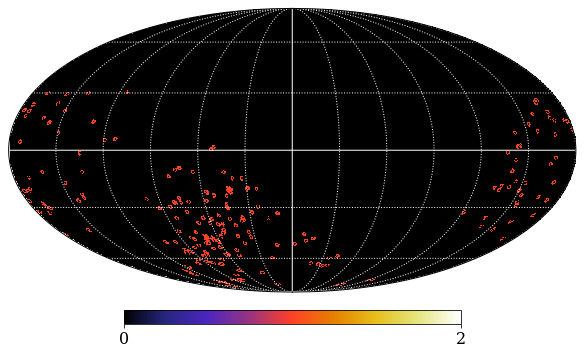

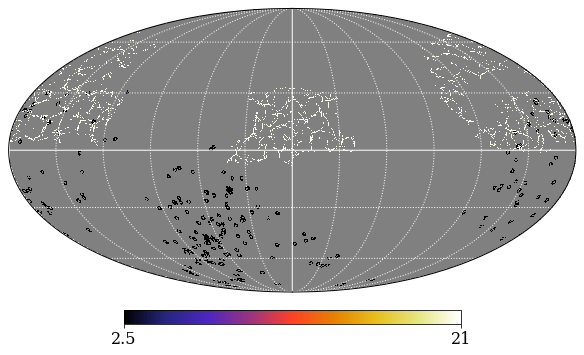

In [17]:
cmap = copy.copy(mpl.cm.get_cmap("CMRmap"))
cmap2 = copy.copy(mpl.cm.get_cmap("coolwarm"))

ax1 = fo.healpy_mollview(clu_map_with_discs, cmap=cmap, vmin=0+2.5, vmax=2.8)
ax2 = fo.healpy_mollview(filament_map+clu_map_with_discs, cmap=cmap, vmin=2.5, vmax=8.5,
                        norm='log')

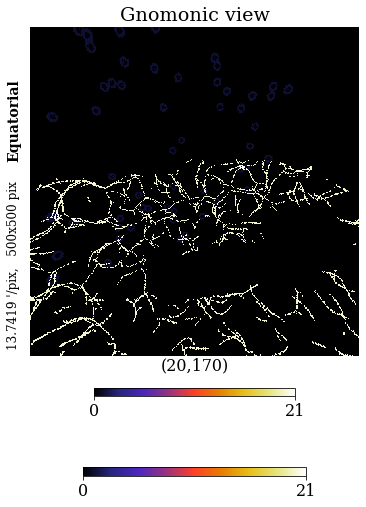

In [18]:
cmap = copy.copy(mpl.cm.get_cmap("CMRmap"))

fig = plt.figure(figsize=(8,9))
ax = plt.subplot(111)

hp.gnomview(filament_map+clu_map_with_discs, rot=[center_ra, center_dec, 0 ], coord='C',
           xsize=9500, ysize=9500, nest=True, hold=True, cmap=cmap, reso=reso)
hp.gnomview(filament_map+clu_map_with_discs, rot=[center_ra, center_dec, 0 ], coord='C',
           xsize=500, ysize=500, nest=True, hold=True, cmap=cmap, reso=reso)

fo.set_labels(ax, "RA", "dec", title="Using gnomview", legend=False)
ax.set_title("Using gnomview", color='w')
fig.patch.set_facecolor('white')

In [19]:
def make_filaments_fatter(ra_fil, dec_fil, filament_map, NSIDE=256, factor_widen=2,
                         fill_pixel_value=3, return_pixel_idx=False):
    vec_clu = hp.ang2vec(ra_fil, dec_fil, lonlat=True)
    reso = hp.pixelfunc.nside2resol(NSIDE)
    
    fatter_filament_map = np.copy(filament_map)
    for vec in vec_clu:
        circle = hp.query_disc(NSIDE, vec, radius=factor_widen*reso, nest=True) 
        
        fatter_filament_map[circle] = fill_pixel_value
    return fatter_filament_map

In [20]:
filament_map_1, filament_map_1_idx = fo.produce_healpy_map(NSIDE, ra_fil, dec_fil, fil_val=1,
                                                           return_pixel_idx=True)

fatter_filament_map = make_filaments_fatter(ra_fil, dec_fil, filament_map_1, factor_widen=3,
                                           fill_pixel_value=val_filament)
fatter_filament_map_1 = make_filaments_fatter(ra_fil, dec_fil, filament_map_1, factor_widen=3,
                                           fill_pixel_value=1)

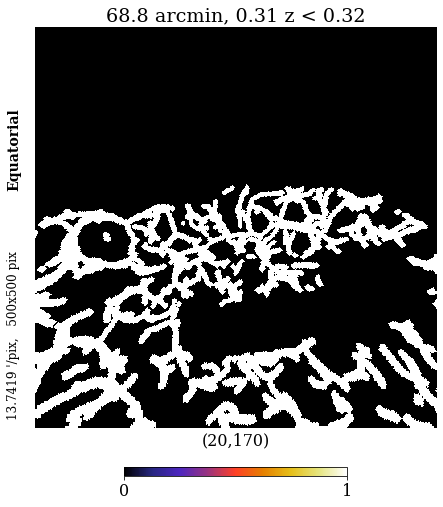

In [21]:
cmap = copy.copy(mpl.cm.get_cmap("CMRmap"))

fig = plt.figure(figsize=(8,9))
ax = plt.subplot(111)

gview_arr = hp.gnomview(fatter_filament_map_1, rot=[center_ra, center_dec, 0 ],
            coord='C', xsize=500, ysize=500, nest=True, hold=True, cmap=cmap,
           title=f"{.02*u.rad.to(u.arcmin):.1f} arcmin, {z_low} z < {z_high}",
           reso=reso, return_projected_map=True)

fig.patch.set_facecolor('white')

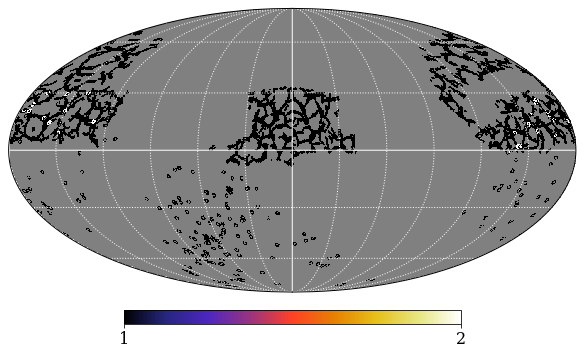

In [22]:
cmap = copy.copy(mpl.cm.get_cmap("CMRmap"))
cmap2 = copy.copy(mpl.cm.get_cmap("coolwarm"))

ax2 = fo.healpy_mollview(fatter_filament_map_1+clu_map_with_discs, cmap=cmap, vmin=1,
                        norm='log')

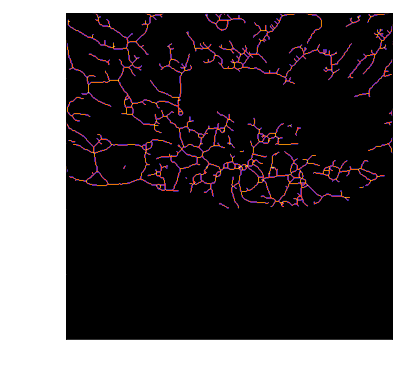

In [23]:
skeleton_gview = skeletonize(gview_arr.data)
fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.imshow(skeleton_gview, cmap=cmap)
fo.set_as_white(ax)
fo.set_labels(ax, 'Dec [degs]', 'R.A. [degs]', legend=False)

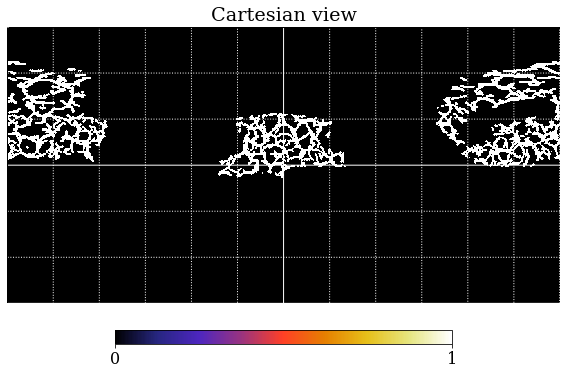

In [24]:
cmap = copy.copy(mpl.cm.get_cmap("CMRmap"))
cmap2 = copy.copy(mpl.cm.get_cmap("coolwarm"))

fig = plt.figure(figsize=(14,6.2))
ax = plt.subplot(111,  projection="mollweide")

cartview_arr = hp.cartview(fatter_filament_map_1, nest=True, 
                           cmap=cmap, hold=True, fig=1, 
                           return_projected_map=True)
hp.graticule(color='w')
fig.patch.set_facecolor('white')

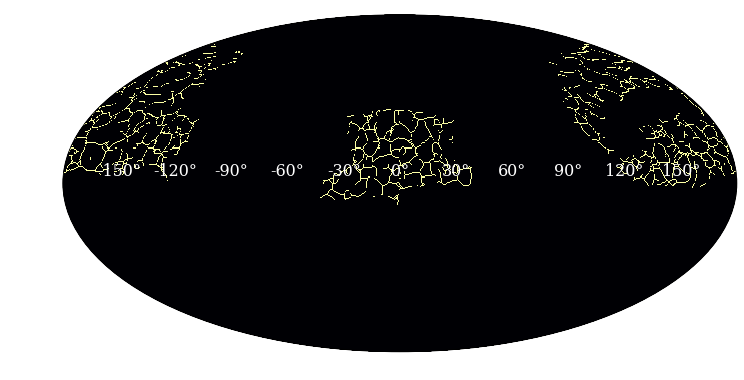

In [25]:
skeleton = skeletonize(cartview_arr.data)
fig = plt.figure(figsize=(14,6.2))
ax = plt.subplot(111, projection="mollweide")

lon = np.linspace(-np.pi, np.pi, skeleton.shape[1])
lat = np.linspace(-np.pi/2., np.pi/2., skeleton.shape[0])
Lon,Lat = np.meshgrid(lon,lat)

ax.pcolormesh(Lon, Lat, skeleton, cmap='inferno', shading='auto')
ax.grid(True, color='w')
fo.set_as_white(ax)
fo.set_labels(ax, 'Dec [degs]', 'R.A. [degs]', legend=False)

Here again we need to go from the 2D skeleton array to the 1D healpy map array that we can then use for manipulation to estimate how many neighbours each pixel has.

In [26]:
filament_skeleton_map = fo.twoDarray2map(skeleton)

<MollweideAxesSubplot:>

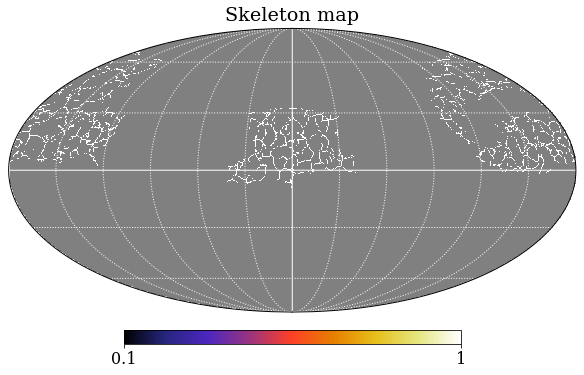

In [27]:
fo.healpy_mollview(filament_skeleton_map, cmap=cmap, norm='log',
                   title='Skeleton map')

In [28]:
non_zero_pixel_ids = np.where(filament_skeleton_map==1)[0]

<AxesSubplot:title={'center':'NSIDE=256'}, xlabel='Number of filament neighbours', ylabel='Counts'>

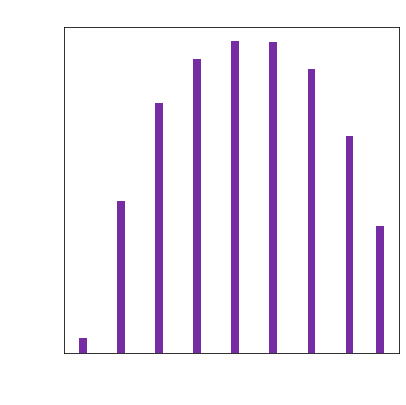

In [29]:
neighbours = hp.pixelfunc.get_all_neighbours(NSIDE, non_zero_pixel_ids, nest=True)
vals_neighbours = np.zeros(neighbours.shape)
vals_neighbours = filament_skeleton_map[neighbours]
    
fig, ax = plt.subplots(1, 1, figsize=(6,6))
values = ax.hist(np.sum(vals_neighbours, axis=0), bins=40, color='#762ca3')
fo.set_labels(ax, "Number of filament neighbours", "Counts", title=f"NSIDE={NSIDE}", legend=False)
ax.set_yscale("log")
fo.set_as_white(ax)

In [30]:
number_neighbours = np.zeros(len(filament_skeleton_map))
number_neighbours[non_zero_pixel_ids] = np.sum(vals_neighbours, axis=0)

In [41]:
ends = (0<number_neighbours) & (number_neighbours<=2)
filaments = (2<number_neighbours) & (number_neighbours<=6)
nodes = number_neighbours>=6
print(len(np.where(ends)[0]), len(np.where(filaments)[0]), len(np.where(nodes)[0]))

1297 15104 3178


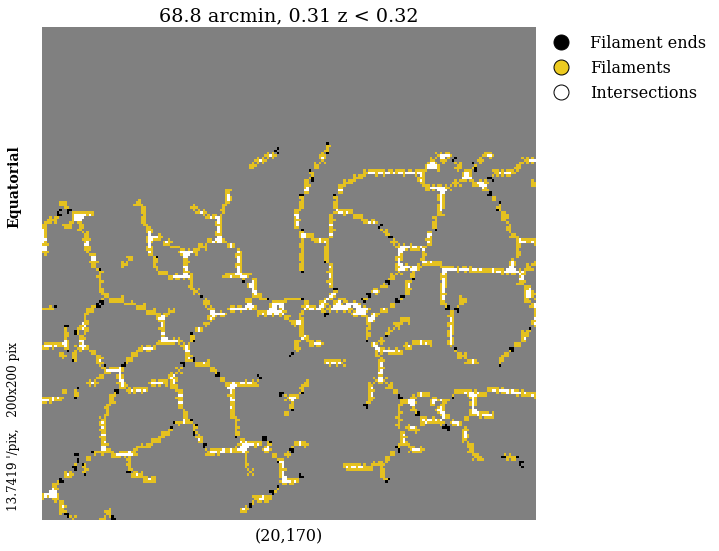

In [42]:
classified_fil_map = np.copy(filament_skeleton_map)
classified_fil_map[ends]=4
classified_fil_map[filaments]=8
classified_fil_map[nodes]=10

fig = plt.figure(figsize=(9,7))
ax = plt.subplot(111)
ax.axis('off')

hp.gnomview(classified_fil_map, rot=[center_ra, center_dec, 0 ],
        coord='C', xsize=200, ysize=200, nest=True,cmap=cmap,
       title=f"{.02*u.rad.to(u.arcmin):.1f} arcmin, {z_low} z < {z_high}",
       reso=reso, norm='log', cbar=False, min=4, sub=(1, 1, 1), )

labels=['Filament ends', 'Filaments', 'Intersections']
legend_elements = []

colors = ['k', 
          '#edcb21', 
          'w']
for c, l in zip(colors, labels):
    legend_elements.append(Line2D([0], [0], ls='', marker='o', color=c, label=l, mfc=c, ms=15, mec='k'))
ax.legend(handles=legend_elements, bbox_to_anchor=(1.35, 1.15), frameon=False)

fig.patch.set_facecolor('white')
fig.savefig(f'{image_dir}/classifying_the_filament_cat_w_title.png', format='png')

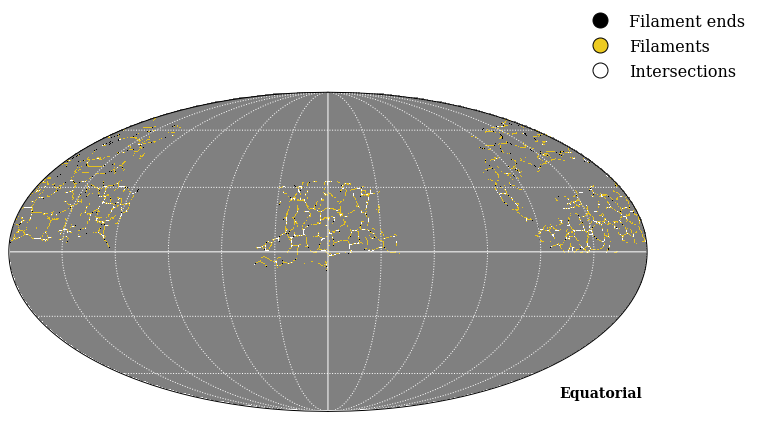

In [43]:
fig = plt.figure(figsize=(9,7))
ax = plt.subplot(111)
ax.axis('off')

hp.mollview(classified_fil_map, coord='C', nest=True,cmap=cmap,
       title='',
       norm='log', cbar=False, min=4, sub=(1, 1, 1), )
hp.graticule(color='w')

labels=['Filament ends', 'Filaments', 'Intersections']
legend_elements = []

colors = ['k', 
          '#edcb21', 
          'w']
for c, l in zip(colors, labels):
    legend_elements.append(Line2D([0], [0], ls='', marker='o', color=c, label=l, mfc=c, ms=15, mec='k'))
ax.legend(handles=legend_elements, bbox_to_anchor=(1.35, 1.15), frameon=False)

fig.patch.set_facecolor('white')
fig.savefig(f'{image_dir}/classifying_the_filament_cat_zoom_out.png', format='png')

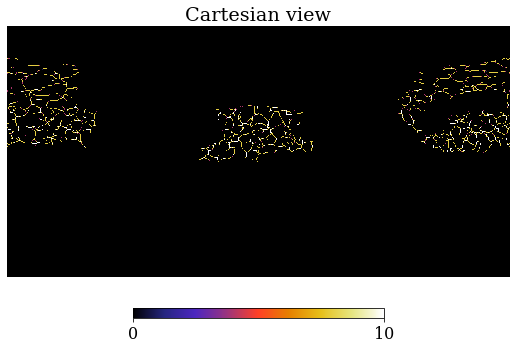

In [48]:
fig = plt.figure(figsize=(9,7))
ax = plt.subplot(111)
ax.axis('off')


cartview_arr_classified = hp.cartview(classified_fil_map, nest=True, 
                           cmap=cmap, hold=True, fig=1, 
                           return_projected_map=True)

labels=['Filament ends', 'Filaments', 'Intersections']
legend_elements = []

colors = ['k', 
          '#edcb21', 
          'w']
for c, l in zip(colors, labels):
    legend_elements.append(Line2D([0], [0], ls='', marker='o', color=c, label=l, mfc=c, ms=15, mec='k'))
ax.legend(handles=legend_elements, bbox_to_anchor=(1.35, 1.15), frameon=False)

fig.patch.set_facecolor('white')
fig.savefig(f'{image_dir}/cart_view_classifying_the_filcat_zoom_out.png', format='png')

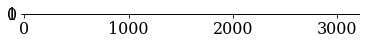

In [51]:
filaments_arr = np.array([], dtype=object)
for i in range(len(classified_fil_map)):
    np.where()

In [82]:
def make_tuple_array(arr, val):
    coord_x, coord_y = np.where(arr == val)[0], np.where(arr == val)[1]
    coord_xy = [(x, y) for x, y in zip(coord_x, coord_y)]
    return coord_xy

node_xy = make_tuple_array(cartview_arr_classified, 4)
fil_xy = make_tuple_array(cartview_arr_classified, 8)
end_xy = make_tuple_array(cartview_arr_classified, 10)

In [190]:
x0, y0 = fil_xy[0]
filament_ID = 0
fil_ID_arr = np.array([])
delta_xy = 2

def add_delta(x0, y0, delta_xy, arr):
    arr.append([(x0+delta_xy, y0), (x0, y0+delta_xy)])
    return arr

def define_grid(x0, y0, pix: int=2):
    arr = []
    for i in range(pix):
        arr = add_delta(x0, y0, i, arr)
    return arr

for position in fil_xy[1:]:
    new_pos = define_grid(x0, y0, pix=2)
    if position in new_pos:
        print("ok")
        # and give it the same ID
        fil_ID_arr = np.append(fil_ID_arr, filament_ID)
        
        # update the last filament position
        x0, y0 = position
    else:
        # or is the position in a node or end?
        unidentified_pos = define_grid(x0, y0, pix=2)
        for pt in unidentidied_pos:
            if pt in node_xy:
                print("node")
                filament_ID += 1
                # end the filament
            if pt in end_xy: 
                print("end")
                filament_ID += 1
        
        x0, y0 = position

In [142]:
(184.+1, 322.) in node_xy

False

In [197]:
fil_xy.index((183, 336)), fil_xy[3]

(3, (183, 336))

In [206]:
np.where((183 == np.array(fil_xy)[:, 0]) & (336 == np.array(fil_xy)[:, 1]))

(array([3]),)

In [205]:
np.array(fil_xy)[3]

array([183, 336])

In [ ]:
hp.boundaries(nside=NSIDE, )

In [211]:
len(fil_xy), len(cartview_arr_classified)**2, len(node_xy), len(end_xy)

(3210, 160000, 500, 1405)